# Exploração inicial de preços de ações
Notebook para inspecionar rapidamente a série de fechamentos históricos antes de treinar o modelo.

In [1]:
import yfinance as yf
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8')

TICKER = 'PETR4.SA'  # altere aqui se quiser outro ativo
PERIOD = '5y'    # janela de dados a baixar
INTERVAL = '1d'  # granularidade

In [2]:
# Baixa os dados
df = yf.download(TICKER, period=PERIOD, interval=INTERVAL, progress=False)
if df.empty or 'Close' not in df:
    raise ValueError(f'Nenhum dado encontrado para {TICKER}.')
df.info()
df = df.rename(columns={'Close': 'close'})
df.head()

<class 'pandas.DataFrame'>
DatetimeIndex: 1248 entries, 2021-02-18 to 2026-02-18
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   (Close, PETR4.SA)   1248 non-null   float64
 1   (High, PETR4.SA)    1248 non-null   float64
 2   (Low, PETR4.SA)     1248 non-null   float64
 3   (Open, PETR4.SA)    1248 non-null   float64
 4   (Volume, PETR4.SA)  1248 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 58.5 KB


Price,close,High,Low,Open,Volume
Ticker,PETR4.SA,PETR4.SA,PETR4.SA,PETR4.SA,PETR4.SA
Date,,,,,
2021-02-18,8.405582,8.879419,8.339533,8.724345,105539200
2021-02-19,7.848467,8.181589,7.802520,8.049489,215834800
2021-02-22,6.223062,6.662439,6.145525,6.547568,490230400
2021-02-23,6.909408,6.966843,6.521723,6.619362,293503100
2021-02-24,7.007047,7.179352,6.895049,7.050123,155246400


In [3]:
# Resumo estatístico básico
df[['close']].describe()

Price,close
Ticker,PETR4.SA
count,1248.000000
mean,21.107693
std,9.332227
min,6.059373
25%,12.194207
50%,21.386045
75%,30.113944
max,38.080002


In [4]:
# Checa valores ausentes por coluna
df.isna().sum()

Price   Ticker  
close   PETR4.SA    0
High    PETR4.SA    0
Low     PETR4.SA    0
Open    PETR4.SA    0
Volume  PETR4.SA    0
dtype: int64

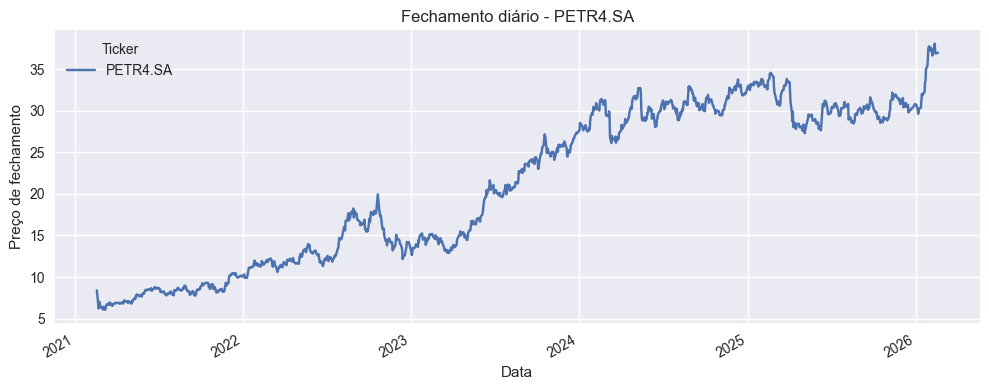

In [5]:
# Plot da série completa
df['close'].plot(figsize=(10, 4), title=f'Fechamento diário - {TICKER}')
plt.xlabel('Data')
plt.ylabel('Preço de fechamento')
plt.tight_layout()
plt.show()

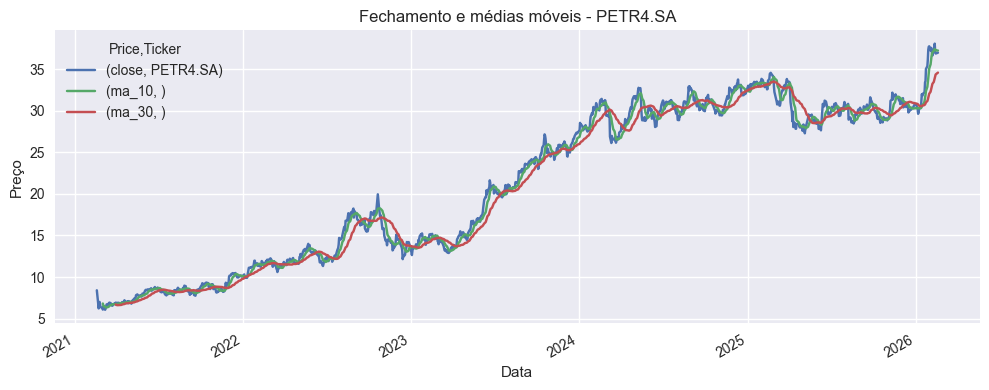

In [6]:
# Médias móveis para ver tendência de curto/médio prazo
df['ma_10'] = df['close'].rolling(window=10).mean()
df['ma_30'] = df['close'].rolling(window=30).mean()
ax = df[['close','ma_10','ma_30']].plot(figsize=(10, 4), title=f'Fechamento e médias móveis - {TICKER}')
ax.set_xlabel('Data')
ax.set_ylabel('Preço')
plt.tight_layout()
plt.show()

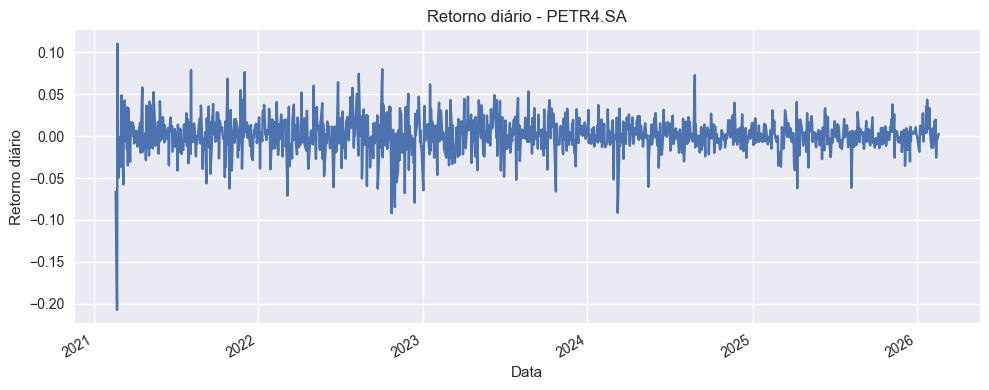

count    1247.000000
mean        0.001418
std         0.021281
min        -0.207098
1%         -0.061849
5%         -0.032219
25%        -0.008529
50%         0.001311
75%         0.012507
95%         0.033918
99%         0.053994
max         0.110291
Name: return, dtype: float64

In [7]:
# Variação percentual diária (retornos)
df['return'] = df['close'].pct_change()
df['return'].plot(figsize=(10, 4), title=f'Retorno diário - {TICKER}')
plt.xlabel('Data')
plt.ylabel('Retorno diário')
plt.tight_layout()
plt.show()

df['return'].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])

In [8]:
# Correlação entre fechamento e volume, se volume disponível
if 'Volume' in df.columns:
    corr = df[['close','Volume']].corr().iloc[0,1]
    print(f'Correlação close x volume: {corr:.4f}')
else:
    print('Volume não disponível para este ativo/período.')

Correlação close x volume: -0.5317
